In [1]:
###testing R in jyupter 

In [2]:
library(purrr)
library(tidyverse)
library(edgeR)

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.3.6     ✔ dplyr   1.0.9
✔ tibble  3.1.7     ✔ stringr 1.4.0
✔ tidyr   1.2.0     ✔ forcats 0.5.1
✔ readr   2.1.2     

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()

Loading required package: limma



In [3]:
lfbl=function(pattern,level=1){
    if(!exists("lof")) lof=vector("character",0)
    temp=list.files(pattern=pattern,no..=T)
    if(!is.na(temp[1])) lof=c(lof,paste0(getwd(),"/",temp))
    if(level>0){
        dirf=list.dirs(full.names=F,recursive=F)
        for(i in dirf){
            setwd(i)
            lof=c(lof,lfbl(pattern,level-1))
            setwd("..")
        }
    }
    return(lof)
}




In [4]:
setwd("/lustre/scratch123/hgi/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/")
getwd()

[1] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount"

In [5]:
f_files = lfbl(pattern = '20.5dpp.[1-3].raw.count.gz$',level=0)
f_files


[1] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/129S1_SvImJ-20.5dpp.1.raw.count.gz"
 [2] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/129S1_SvImJ-20.5dpp.2.raw.count.gz"
 [3] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/129S1_SvImJ-20.5dpp.3.raw.count.gz"
 [4] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/A_J-20.5dpp.1.raw.count.gz"        
 [5] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/A_J-20.5dpp.2.raw.count.gz"        
 [6] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/A_J-20.5dpp.3.raw.count.gz"        
 [7] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/AKR_J-20.5dpp.1.raw.count.gz"      
 [8] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/AKR_J-20.5dpp.2.raw.count.gz"      
 [9] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/AKR_J-20.5dpp.3.raw.count.gz"      
[10] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/BALB_cJ-20.5dpp.1.raw.count.gz"    
[11] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/BALB_cJ-20.5dpp.2.raw.count.gz"    
[12] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/BALB_cJ-20.5dpp.3.raw.count.gz"    
[13] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/C3H_HeJ-20.5dpp.1.raw.count.gz"    
[14] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/C3H_HeJ-20.5dpp.2.raw.count.gz"    
[15] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/C3H_HeJ-20.5dpp.3.raw.count.gz"    
[16] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/C57BL_6NJ-20.5dpp.1.raw.count.gz"  
[17] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/C57BL_6NJ-20.5dpp.2.raw.count.gz"  
[18] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/C57BL_6NJ-20.5dpp.3.raw.count.gz"  
[19] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/CAST_EiJ-20.5dpp.1.raw.count.gz"   
[20] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/CAST_EiJ-20.5dpp.2.raw.count.gz"   
[21] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/CAST_EiJ-20.5dpp.3.raw.count.gz"   
[22] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/CBA_J-20.5dpp.1.raw.count.gz"      
[23] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/CBA_J-20.5dpp.2.raw.count.gz"      
[24] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/CBA_J-20.5dpp.3.raw.count.gz"      
[25] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/DBA_2J-20.5dpp.1.raw.count.gz"     
[26] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/DBA_2J-20.5dpp.2.raw.count.gz"     
[27] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/DBA_2J-20.5dpp.3.raw.count.gz"     
[28] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/FVB_NJ-20.5dpp.1.raw.count.gz"     
[29] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/FVB_NJ-20.5dpp.2.raw.count.gz"     

In [6]:

samplenames = tools::file_path_sans_ext(tools::file_path_sans_ext(tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T)))))
samplenames

[1] "129S1_SvImJ-20.5dpp" "129S1_SvImJ-20.5dpp" "129S1_SvImJ-20.5dpp"
 [4] "A_J-20.5dpp"         "A_J-20.5dpp"         "A_J-20.5dpp"        
 [7] "AKR_J-20.5dpp"       "AKR_J-20.5dpp"       "AKR_J-20.5dpp"      
[10] "BALB_cJ-20.5dpp"     "BALB_cJ-20.5dpp"     "BALB_cJ-20.5dpp"    
[13] "C3H_HeJ-20.5dpp"     "C3H_HeJ-20.5dpp"     "C3H_HeJ-20.5dpp"    
[16] "C57BL_6NJ-20.5dpp"   "C57BL_6NJ-20.5dpp"   "C57BL_6NJ-20.5dpp"  
[19] "CAST_EiJ-20.5dpp"    "CAST_EiJ-20.5dpp"    "CAST_EiJ-20.5dpp"   
[22] "CBA_J-20.5dpp"       "CBA_J-20.5dpp"       "CBA_J-20.5dpp"      
[25] "DBA_2J-20.5dpp"      "DBA_2J-20.5dpp"      "DBA_2J-20.5dpp"     
[28] "FVB_NJ-20.5dpp"      "FVB_NJ-20.5dpp"      "FVB_NJ-20.5dpp"     
[31] "LP_J-20.5dpp"        "LP_J-20.5dpp"        "LP_J-20.5dpp"       
[34] "NOD_ShiLtJ-20.5dpp"  "NOD_ShiLtJ-20.5dpp"  "NOD_ShiLtJ-20.5dpp" 
[37] "NZO_HlLtJ-20.5dpp"   "NZO_HlLtJ-20.5dpp"   "NZO_HlLtJ-20.5dpp"  
[40] "PWK_PhJ-20.5dpp"     "PWK_PhJ-20.5dpp"     "PWK_PhJ-20.5dpp"    
[43] "SPRET_EiJ-20.5dpp"   "SPRET_EiJ-20.5dpp"   "SPRET_EiJ-20.5dpp"  
[46] "WSB_EiJ-20.5dpp"     "WSB_EiJ-20.5dpp"     "WSB_EiJ-20.5dpp"

In [7]:

#list of sample names with replicates 
lables = tools::file_path_sans_ext(tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T))))

lables

[1] "129S1_SvImJ-20.5dpp.1" "129S1_SvImJ-20.5dpp.2" "129S1_SvImJ-20.5dpp.3"
 [4] "A_J-20.5dpp.1"         "A_J-20.5dpp.2"         "A_J-20.5dpp.3"        
 [7] "AKR_J-20.5dpp.1"       "AKR_J-20.5dpp.2"       "AKR_J-20.5dpp.3"      
[10] "BALB_cJ-20.5dpp.1"     "BALB_cJ-20.5dpp.2"     "BALB_cJ-20.5dpp.3"    
[13] "C3H_HeJ-20.5dpp.1"     "C3H_HeJ-20.5dpp.2"     "C3H_HeJ-20.5dpp.3"    
[16] "C57BL_6NJ-20.5dpp.1"   "C57BL_6NJ-20.5dpp.2"   "C57BL_6NJ-20.5dpp.3"  
[19] "CAST_EiJ-20.5dpp.1"    "CAST_EiJ-20.5dpp.2"    "CAST_EiJ-20.5dpp.3"   
[22] "CBA_J-20.5dpp.1"       "CBA_J-20.5dpp.2"       "CBA_J-20.5dpp.3"      
[25] "DBA_2J-20.5dpp.1"      "DBA_2J-20.5dpp.2"      "DBA_2J-20.5dpp.3"     
[28] "FVB_NJ-20.5dpp.1"      "FVB_NJ-20.5dpp.2"      "FVB_NJ-20.5dpp.3"     
[31] "LP_J-20.5dpp.1"        "LP_J-20.5dpp.2"        "LP_J-20.5dpp.3"       
[34] "NOD_ShiLtJ-20.5dpp.1"  "NOD_ShiLtJ-20.5dpp.2"  "NOD_ShiLtJ-20.5dpp.3" 
[37] "NZO_HlLtJ-20.5dpp.1"   "NZO_HlLtJ-20.5dpp.2"   "NZO_HlLtJ-20.5dpp.3"  
[40] "PWK_PhJ-20.5dpp.1"     "PWK_PhJ-20.5dpp.2"     "PWK_PhJ-20.5dpp.3"    
[43] "SPRET_EiJ-20.5dpp.1"   "SPRET_EiJ-20.5dpp.2"   "SPRET_EiJ-20.5dpp.3"  
[46] "WSB_EiJ-20.5dpp.1"     "WSB_EiJ-20.5dpp.2"     "WSB_EiJ-20.5dpp.3"

In [8]:
	
df = readDGE(f_files, path=NULL, columns=c(1,3), group= samplenames, labels = lables,sep="\t" )

In [9]:
head(df)

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
129S1_SvImJ-20.5dpp.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/129S1_SvImJ-20.5dpp.1.raw.count.gz,129S1_SvImJ-20.5dpp,37692739,1
129S1_SvImJ-20.5dpp.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/129S1_SvImJ-20.5dpp.2.raw.count.gz,129S1_SvImJ-20.5dpp,37161748,1
129S1_SvImJ-20.5dpp.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/129S1_SvImJ-20.5dpp.3.raw.count.gz,129S1_SvImJ-20.5dpp,35835355,1
A_J-20.5dpp.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/A_J-20.5dpp.1.raw.count.gz,A_J-20.5dpp,29816434,1
A_J-20.5dpp.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/A_J-20.5dpp.2.raw.count.gz,A_J-20.5dpp,34165306,1
A_J-20.5dpp.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/A_J-20.5dpp.3.raw.count.gz,A_J-20.5dpp,39206762,1
AKR_J-20.5dpp.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/AKR_J-20.5dpp.1.raw.count.gz,AKR_J-20.5dpp,34094849,1
AKR_J-20.5dpp.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/AKR_J-20.5dpp.2.raw.count.gz,AKR_J-20.5dpp,38794058,1
AKR_J-20.5dpp.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/AKR_J-20.5dpp.3.raw.count.gz,AKR_J-20.5dpp,38063412,1


In [10]:
mircounts <- df$counts

In [11]:
dim(mircounts)

[1] 120214863        48

In [12]:
head(mircounts,n=100)

,129S1_SvImJ-20.5dpp.1,129S1_SvImJ-20.5dpp.2,129S1_SvImJ-20.5dpp.3,A_J-20.5dpp.1,A_J-20.5dpp.2,A_J-20.5dpp.3,AKR_J-20.5dpp.1,AKR_J-20.5dpp.2,AKR_J-20.5dpp.3,BALB_cJ-20.5dpp.1,⋯,NZO_HlLtJ-20.5dpp.3,PWK_PhJ-20.5dpp.1,PWK_PhJ-20.5dpp.2,PWK_PhJ-20.5dpp.3,SPRET_EiJ-20.5dpp.1,SPRET_EiJ-20.5dpp.2,SPRET_EiJ-20.5dpp.3,WSB_EiJ-20.5dpp.1,WSB_EiJ-20.5dpp.2,WSB_EiJ-20.5dpp.3
TTGGCTAAGATCAAGTGTAGTATCTGTTCT,157578,146335,112076,74341,76192,67069,141966,146425,148563,239560,⋯,49435,68379,117786,205829,147823,249290,306409,297960,117708,108775
ACTCGAGACTGTGTAGAACCTTCATAGGCTT,151264,135592,108661,51212,53555,61034,138291,144297,169113,230022,⋯,200511,24428,107079,183414,37,47,33,247290,165245,148642
TCAGATACAGATATAAGAACTTCATACTTGC,148754,197164,144472,114165,110599,98229,151834,159233,179712,405294,⋯,80498,185335,310772,584098,27532,33448,43923,624381,334702,290389
CTCCAGATTAAAAAATGTCCTAAGTTAGAGCT,122380,103855,85607,65424,77216,73702,155713,174708,165811,236005,⋯,142237,122417,197443,234541,74,62,228,545087,237921,232525
ACTCGAGACTGTGTAGAACCTTCATAGGCTTT,104928,89366,74475,30228,22255,35070,95593,100971,118733,133429,⋯,148163,8887,70164,121814,28,25,14,148910,113280,105334
TAGAACTTGCAGAACATGGGCTATCCCCATC,92436,88840,77442,64079,70659,71559,66164,71498,76931,203670,⋯,57806,68387,95327,184725,100192,147271,185963,263082,139728,127708
ACTCGAGACTGTGTAGAACCTTCATAGGC,82715,92877,63421,29345,32427,34277,68278,72303,89495,137353,⋯,98351,20482,43690,75823,15,22,18,189006,81413,66644
TCAATAAATATTTGTAGAATGCATGAATGA,76149,79203,81774,35737,38597,40075,38650,44110,48610,251788,⋯,143392,70753,103942,193119,100422,167439,211545,222164,136230,133487
TACCAGTTGGATAATGCACTTCCTATT,70603,64361,77282,40620,46322,59940,23403,26824,24752,292519,⋯,79884,71857,96847,199056,35,38,53,248843,213423,194029
TATGAGCTCTATCGGGTTTCTGAACCCTT,59976,46332,64377,32121,37849,50828,23133,26505,25688,183300,⋯,71024,51536,84600,165005,26,30,40,178480,137742,113983


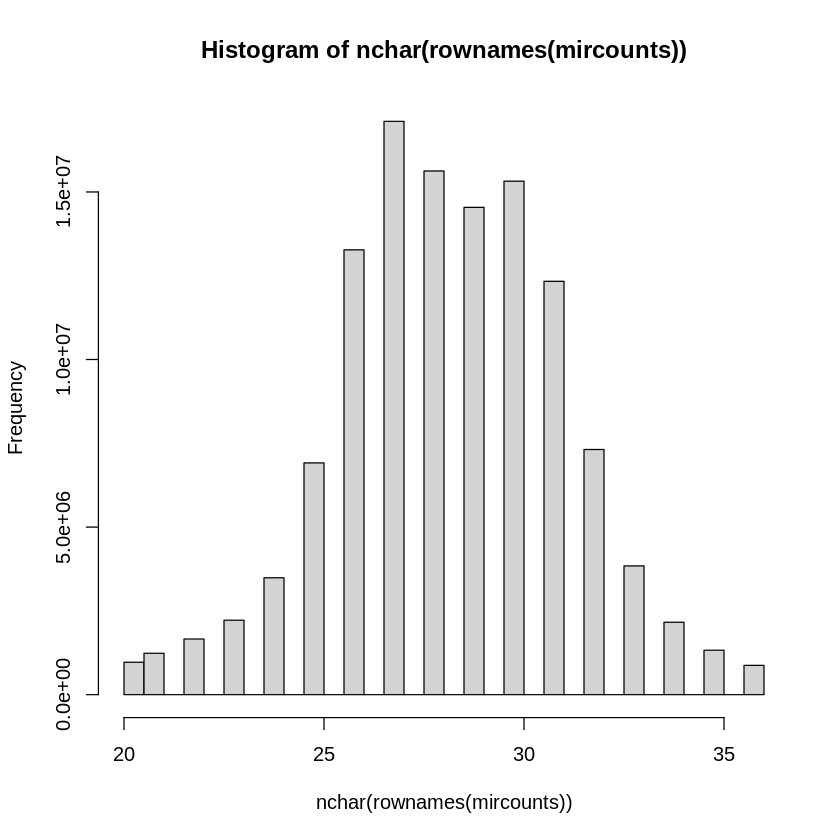

In [13]:
hist(nchar(rownames(mircounts)))

In [14]:
#filter pirna from size 25 to 33

mircounts <- mircounts[nchar(rownames(mircounts)) == 27 | nchar(rownames(mircounts)) == 30,]
dim(mircounts)

[1] 32429055       48

In [15]:
setwd("/lustre/scratch123/hgi/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/analysis/seqCount/raw")
write.table(mircounts, file = "raw_count_matrix_20.5dpp.txt", sep = "\t",
            row.names = TRUE, col.names = TRUE)

In [16]:
df$samples

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
129S1_SvImJ-20.5dpp.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/129S1_SvImJ-20.5dpp.1.raw.count.gz,129S1_SvImJ-20.5dpp,37692739,1
129S1_SvImJ-20.5dpp.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/129S1_SvImJ-20.5dpp.2.raw.count.gz,129S1_SvImJ-20.5dpp,37161748,1
129S1_SvImJ-20.5dpp.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/129S1_SvImJ-20.5dpp.3.raw.count.gz,129S1_SvImJ-20.5dpp,35835355,1
A_J-20.5dpp.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/A_J-20.5dpp.1.raw.count.gz,A_J-20.5dpp,29816434,1
A_J-20.5dpp.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/A_J-20.5dpp.2.raw.count.gz,A_J-20.5dpp,34165306,1
A_J-20.5dpp.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/A_J-20.5dpp.3.raw.count.gz,A_J-20.5dpp,39206762,1
AKR_J-20.5dpp.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/AKR_J-20.5dpp.1.raw.count.gz,AKR_J-20.5dpp,34094849,1
AKR_J-20.5dpp.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/AKR_J-20.5dpp.2.raw.count.gz,AKR_J-20.5dpp,38794058,1
AKR_J-20.5dpp.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/seqCount/AKR_J-20.5dpp.3.raw.count.gz,AKR_J-20.5dpp,38063412,1


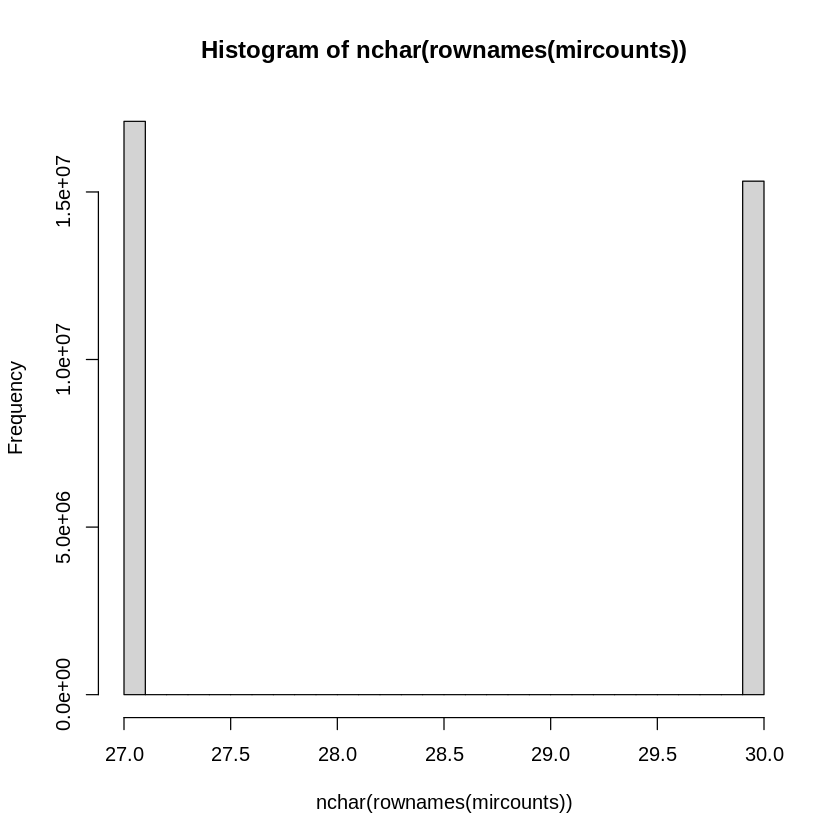

In [17]:
hist(nchar(rownames(mircounts)))

In [18]:
#DESeq and PCA and Dandogram 


library("DESeq2")
library("gplots")
library("RColorBrewer")
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)

#save results in this folder 
setwd("/lustre/scratch123/hgi/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/analysis/seqCount/raw")

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tapply,
    union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:dplyr’:

    first, rename


The following object is masked from ‘packa

In [19]:
# Make a color scheme for heatmaps
hmcol = colorRampPalette(brewer.pal(9, "GnBu"))(100)

In [20]:
# First we tell DESeq which samples correspond to which tissues.

conds = data.frame(samplenames) ##what Desq2 manual calls coldata
colnames(conds)="sample"
samplenames 



[1] "129S1_SvImJ-20.5dpp" "129S1_SvImJ-20.5dpp" "129S1_SvImJ-20.5dpp"
 [4] "A_J-20.5dpp"         "A_J-20.5dpp"         "A_J-20.5dpp"        
 [7] "AKR_J-20.5dpp"       "AKR_J-20.5dpp"       "AKR_J-20.5dpp"      
[10] "BALB_cJ-20.5dpp"     "BALB_cJ-20.5dpp"     "BALB_cJ-20.5dpp"    
[13] "C3H_HeJ-20.5dpp"     "C3H_HeJ-20.5dpp"     "C3H_HeJ-20.5dpp"    
[16] "C57BL_6NJ-20.5dpp"   "C57BL_6NJ-20.5dpp"   "C57BL_6NJ-20.5dpp"  
[19] "CAST_EiJ-20.5dpp"    "CAST_EiJ-20.5dpp"    "CAST_EiJ-20.5dpp"   
[22] "CBA_J-20.5dpp"       "CBA_J-20.5dpp"       "CBA_J-20.5dpp"      
[25] "DBA_2J-20.5dpp"      "DBA_2J-20.5dpp"      "DBA_2J-20.5dpp"     
[28] "FVB_NJ-20.5dpp"      "FVB_NJ-20.5dpp"      "FVB_NJ-20.5dpp"     
[31] "LP_J-20.5dpp"        "LP_J-20.5dpp"        "LP_J-20.5dpp"       
[34] "NOD_ShiLtJ-20.5dpp"  "NOD_ShiLtJ-20.5dpp"  "NOD_ShiLtJ-20.5dpp" 
[37] "NZO_HlLtJ-20.5dpp"   "NZO_HlLtJ-20.5dpp"   "NZO_HlLtJ-20.5dpp"  
[40] "PWK_PhJ-20.5dpp"     "PWK_PhJ-20.5dpp"     "PWK_PhJ-20.5dpp"    
[43] "SPRET_EiJ-20.5dpp"   "SPRET_EiJ-20.5dpp"   "SPRET_EiJ-20.5dpp"  
[46] "WSB_EiJ-20.5dpp"     "WSB_EiJ-20.5dpp"     "WSB_EiJ-20.5dpp"

In [21]:
# Now we build a DESeq2 Count dataset and normalize it.
library(BiocParallel)
register(MulticoreParam(3))
cds <- DESeqDataSetFromMatrix(countData = mircounts, colData = conds, design = ~ sample)
#cds <- estimateSizeFactors(cds)
#cds <- estimateDispersions(cds)
#cds <- nbinomWaldTest(cds)
cds <- DESeq(cds, parallel = TRUE)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates: 3 workers

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not re

In [22]:
#rlog normalisations
#rlog() may take a long time with 50 or more samples,
#vst() is a much faster transformation
#rl=rlog(cds)

rl = vst(cds)

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.



In [23]:

pdf("BarGraphBeforeAfter_20.5dpp.pdf")
par(mfrow=c(2,1))

par(mar=c(10,10,0,10)) # increase y-axis margin.
prenorm=apply(mircounts,2,sum)
barplot(prenorm,col=as.factor(samplenames),las=2,names=samplenames,cex.names=0.8,space = 0.1)
postnorm=apply(counts(cds,normalized=TRUE),2,sum)
barplot(postnorm,col=as.factor(samplenames),las=2,names=samplenames,cex.names=0.8,space = 0.1)
dev.off()


png 
  2

In [24]:
prenorm

129S1_SvImJ-20.5dpp.1 129S1_SvImJ-20.5dpp.2 129S1_SvImJ-20.5dpp.3 
             13059022              12956347              12421839 
        A_J-20.5dpp.1         A_J-20.5dpp.2         A_J-20.5dpp.3 
             10282389              11790148              13407901 
      AKR_J-20.5dpp.1       AKR_J-20.5dpp.2       AKR_J-20.5dpp.3 
             11833564              13351455              13259145 
    BALB_cJ-20.5dpp.1     BALB_cJ-20.5dpp.2     BALB_cJ-20.5dpp.3 
             49164148              47623439              50348905 
    C3H_HeJ-20.5dpp.1     C3H_HeJ-20.5dpp.2     C3H_HeJ-20.5dpp.3 
             14333150              35206190              29206109 
  C57BL_6NJ-20.5dpp.1   C57BL_6NJ-20.5dpp.2   C57BL_6NJ-20.5dpp.3 
             34255931              51900373              50096121 
   CAST_EiJ-20.5dpp.1    CAST_EiJ-20.5dpp.2    CAST_EiJ-20.5dpp.3 
             53677685              31836765              44302141 
      CBA_J-20.5dpp.1       CBA_J-20.5dpp.2       CBA_J-20.5dpp.3 
             32455054              12010854              31597136 
     DBA_2J-20.5dpp.1      DBA_2J-20.5dpp.2      DBA_2J-20.5dpp.3 
             13137128              12088480              11291690 
     FVB_NJ-20.5dpp.1      FVB_NJ-20.5dpp.2      FVB_NJ-20.5dpp.3 
             13075179              13177799              12740913 
       LP_J-20.5dpp.1        LP_J-20.5dpp.2        LP_J-20.5dpp.3 
             42071614              23052659              20544180 
 NOD_ShiLtJ-20.5dpp.1  NOD_ShiLtJ-20.5dpp.2  NOD_ShiLtJ-20.5dpp.3 
             17418229              49402399              16676849 
  NZO_HlLtJ-20.5dpp.1   NZO_HlLtJ-20.5dpp.2   NZO_HlLtJ-20.5dpp.3 
             41186636              18460242              11882995 
    PWK_PhJ-20.5dpp.1     PWK_PhJ-20.5dpp.2     PWK_PhJ-20.5dpp.3 
             13965458              21777390              39580564 
  SPRET_EiJ-20.5dpp.1   SPRET_EiJ-20.5dpp.2   SPRET_EiJ-20.5dpp.3 
             26513025              35815970              44093279 
    WSB_EiJ-20.5dpp.1     WSB_EiJ-20.5dpp.2     WSB_EiJ-20.5dpp.3 
             54484730              34862538              29581363

In [25]:
##To plot PC1 versus 2 ## ALways change the colours to alphabetical order, and change the data.frame colData to rl.sub1 or approrpiate
plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], group = group, 
                  intgroup.df, name = colData(rl.sub)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:2]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC2", color = "group", label = "name")) + geom_point(size = 3) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + coord_fixed()+ 
    theme_bw() + ggtitle(timePoint) 
  
}


library(lattice)
strains <- unique(tools::file_path_sans_ext(sub("-[0-9]*", "", samplenames,perl = T)))

for (timePoint in c("20.5")) {
print(timePoint)
rl.sub <- rl[ , rl$sample %in%  grep(paste0(timePoint), samplenames, value = TRUE) ]
pdf(paste0("PCA_After_1vs2_Beginning_",timePoint,".pdf"))
print(plotPCA.san(rl.sub, intgroup = "sample", ntop = nrow(counts(cds))))
dev.off()
}


[1] "20.5"


In [26]:
##To plot PC1 versus 2 ## ALways change the colours to alphabetical order, and change the data.frame colData to rl.sub1 or approrpiate
plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], group = group, 
                  intgroup.df, name = colData(rl)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:2]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC2", color = "group", label = "name")) + geom_point(size = 3) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + coord_fixed()+ 
    theme_bw()+  theme(legend.text=element_text(size=5))
  
}

pdf("PCA_After_1vs2_Beginning_20.5dpp.pdf",paper="a4")
plotPCA.san(rl, intgroup = "sample", ntop = nrow(counts(cds)))
dev.off()

png 
  2

In [27]:
##To plot PC1 versus 2 ## ALways change the colours to alphabetical order, and change the data.frame colData to rl.sub1 or approrpiate
plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], group = group, 
                  intgroup.df, name = colData(rl.sub)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:2]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC2", color = "group", label = "name")) + geom_point(size = 3) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + coord_fixed()+ 
    theme_bw() + ggtitle(strain) 
  
}


library(lattice)
strains <- unique(tools::file_path_sans_ext(sub("-[0-9]*", "", samplenames,perl = T)))

for (strain in strains) {
print(strain)
rl.sub <- rl[ , rl$sample %in%  grep(paste0("^",strain), samplenames, value = TRUE) ]
pdf(paste0("PCA_After_1vs2_Beginning_",strain,".pdf"))
print(plotPCA.san(rl.sub, intgroup = "sample", ntop = nrow(counts(cds))))
dev.off()
}


[1] "129S1_SvImJ"
[1] "A_J"
[1] "AKR_J"
[1] "BALB_cJ"
[1] "C3H_HeJ"
[1] "C57BL_6NJ"
[1] "CAST_EiJ"
[1] "CBA_J"
[1] "DBA_2J"
[1] "FVB_NJ"
[1] "LP_J"
[1] "NOD_ShiLtJ"
[1] "NZO_HlLtJ"
[1] "PWK_PhJ"
[1] "SPRET_EiJ"
[1] "WSB_EiJ"


In [28]:

##To plot PC2 versus 3
library(genefilter)
library(ggplot2)
library(ggrepel)

plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC2 = pca$x[, 2], PC3 = pca$x[, 3], group = group, 
                  intgroup.df, name = colData(rl)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[2:3]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC2", y = "PC3", color = "group", label = "name")) + geom_point(size = 3) + xlab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + ylab(paste0("PC3: ", round(percentVar[3] * 100), "% variance")) + coord_fixed() 
  
}

pdf("PCA_After_3_20.5dpp.pdf",paper="a4")
plotPCA.san(rl, intgroup = 'sample', ntop = nrow(counts(cds)))
dev.off()


Attaching package: ‘genefilter’


The following objects are masked from ‘package:MatrixGenerics’:

    rowSds, rowVars


The following objects are masked from ‘package:matrixStats’:

    rowSds, rowVars


The following object is masked from ‘package:readr’:

    spec




png 
  2

In [29]:
##To plot PC1 versus 3
plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC3 = pca$x[, 3], group = group, 
                  intgroup.df, name = colData(rl)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:3]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC3", color = "group", label = "name")) + geom_point(size = 3) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + ylab(paste0("PC3: ", round(percentVar[3] * 100), "% variance")) + coord_fixed() 
  
}

pdf("PCA_After_4_20.5dpp.pdf",paper="a4")
plotPCA.san(rl, intgroup = 'sample', ntop = nrow(counts(cds)))
dev.off()

png 
  2

In [30]:
####
# Margins area


pdf("InitialHeatMap_20.5dpp.pdf",title="Raw Seq Data",fillOddEven=T)
par(mar=c(0,0,0,0)) 
heatmap.2(cor(mircounts),trace="none",col=hmcol,main="Sample Correlation",cexRow=0.3,cexCol=0.3,key.title = 'Color Key',
    margins=c(10,10),na.rm=T,key=T, keysize = 1.5,offsetRow=0,offsetCol=0,density.info='histogram')
dev.off()



png 
  2

In [31]:
##And the Spearman Dendogram
foo_sub_1 = counts(cds, normalized = TRUE)

foo_cor_1 = cor(foo_sub_1, method = "spearman") #builds matrix of Spearman corrn and euclidean distances

foo_cor_dist_1 = dist(foo_cor_1, method = "euclidean")
pdf(file="dendrogram_20.5dpp.pdf")
par( mar=c(5, 8, 4, 1))
plot(hclust(foo_cor_dist_1), cex = 0.6)
dev.off()

png 
  2

[1] "129S1_SvImJ-20.5dpp.1" "129S1_SvImJ-20.5dpp.2" "129S1_SvImJ-20.5dpp.3"
 [4] "A_J-20.5dpp.1"         "A_J-20.5dpp.2"         "A_J-20.5dpp.3"        
 [7] "AKR_J-20.5dpp.1"       "AKR_J-20.5dpp.2"       "AKR_J-20.5dpp.3"      
[10] "BALB_cJ-20.5dpp.1"     "BALB_cJ-20.5dpp.2"     "BALB_cJ-20.5dpp.3"    
[13] "C3H_HeJ-20.5dpp.1"     "C3H_HeJ-20.5dpp.2"     "C3H_HeJ-20.5dpp.3"    
[16] "C57BL_6NJ-20.5dpp.1"   "C57BL_6NJ-20.5dpp.2"   "C57BL_6NJ-20.5dpp.3"  
[19] "CAST_EiJ-20.5dpp.1"    "CAST_EiJ-20.5dpp.2"    "CAST_EiJ-20.5dpp.3"   
[22] "CBA_J-20.5dpp.1"       "CBA_J-20.5dpp.2"       "CBA_J-20.5dpp.3"      
[25] "DBA_2J-20.5dpp.1"      "DBA_2J-20.5dpp.2"      "DBA_2J-20.5dpp.3"     
[28] "FVB_NJ-20.5dpp.1"      "FVB_NJ-20.5dpp.2"      "FVB_NJ-20.5dpp.3"     
[31] "LP_J-20.5dpp.1"        "LP_J-20.5dpp.2"        "LP_J-20.5dpp.3"       
[34] "NOD_ShiLtJ-20.5dpp.1"  "NOD_ShiLtJ-20.5dpp.2"  "NOD_ShiLtJ-20.5dpp.3" 
[37] "NZO_HlLtJ-20.5dpp.1"   "NZO_HlLtJ-20.5dpp.2"   "NZO_HlLtJ-20.5dpp.3"  
[40] "PWK_PhJ-20.5dpp.1"     "PWK_PhJ-20.5dpp.2"     "PWK_PhJ-20.5dpp.3"    
[43] "SPRET_EiJ-20.5dpp.1"   "SPRET_EiJ-20.5dpp.2"   "SPRET_EiJ-20.5dpp.3"  
[46] "WSB_EiJ-20.5dpp.1"     "WSB_EiJ-20.5dpp.2"     "WSB_EiJ-20.5dpp.3"

TTGGCTAAGATCAAGTGTAGTATCTGTTCT
TCAATAAATATTTGTAGAATGCATGAATGA
TACCAGTTGGATAATGCACTTCCTATT
TTGGAGATTGAATTTTTGAAAAAGCCT
ATGCATTGTAGGATGATTGGCACTATC
TGATACAATTTCTAAGGGCTGTTTAGTAAT


,129S1_SvImJ-20.5dpp,A_J-20.5dpp,AKR_J-20.5dpp,BALB_cJ-20.5dpp,C3H_HeJ-20.5dpp,C57BL_6NJ-20.5dpp,CAST_EiJ-20.5dpp,CBA_J-20.5dpp,DBA_2J-20.5dpp,FVB_NJ-20.5dpp,LP_J-20.5dpp,NOD_ShiLtJ-20.5dpp,NZO_HlLtJ-20.5dpp,PWK_PhJ-20.5dpp,SPRET_EiJ-20.5dpp,WSB_EiJ-20.5dpp
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TTGGCTAAGATCAAGTGTAGTATCTGTTCT,242694.49,129138.88,254788.28,114182.78,254711.82,337335.32,84375.09,228737.21,187925.03,200795.63,193160.11,154309.45,128748.82,115363.4506,1.774908e+05,89598.41
TCAATAAATATTTGTAGAATGCATGAATGA,138411.10,67224.05,76371.19,107055.97,100754.52,63509.94,166088.47,81449.15,77213.15,75024.19,117330.67,71621.31,244804.35,109527.8488,1.207859e+05,89526.97
TACCAGTTGGATAATGCACTTCCTATT,123843.17,85176.53,43621.17,146431.52,53490.93,62489.92,98697.93,51201.81,59721.28,66940.15,117412.87,75420.20,110759.61,108812.9893,3.305836e+01,123684.50
TTGGAGATTGAATTTTTGAAAAAGCCT,56951.71,55240.50,40594.24,44341.57,54175.55,51409.95,33546.73,41208.58,74341.00,48726.30,54465.83,50018.25,67801.08,30.4727,7.429498e+00,32299.88
ATGCATTGTAGGATGATTGGCACTATC,60268.05,48052.43,47247.57,28283.50,40839.59,25678.58,18740.56,38418.01,69865.65,34291.90,62255.97,22764.16,38970.88,24695.6720,3.160682e+04,21794.24
TGATACAATTTCTAAGGGCTGTTTAGTAAT,56565.66,33637.51,55400.72,30191.53,40823.47,49348.24,26977.94,51683.27,36355.40,44430.52,56978.66,39699.55,40082.41,29050.1378,3.454936e+04,26906.22


[1] 32429055

[1] 3959

,129S1_SvImJ-20.5dpp,A_J-20.5dpp,AKR_J-20.5dpp,BALB_cJ-20.5dpp,C3H_HeJ-20.5dpp,C57BL_6NJ-20.5dpp,CAST_EiJ-20.5dpp,CBA_J-20.5dpp,DBA_2J-20.5dpp,FVB_NJ-20.5dpp,LP_J-20.5dpp,NOD_ShiLtJ-20.5dpp,NZO_HlLtJ-20.5dpp,PWK_PhJ-20.5dpp,SPRET_EiJ-20.5dpp,WSB_EiJ-20.5dpp
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TTGGCTAAGATCAAGTGTAGTATCTGTTCT,242694.49,129138.88,254788.28,114182.78,254711.82,337335.32,84375.09,228737.21,187925.03,200795.63,193160.11,154309.45,128748.82,115363.4506,1.774908e+05,89598.41
TCAATAAATATTTGTAGAATGCATGAATGA,138411.10,67224.05,76371.19,107055.97,100754.52,63509.94,166088.47,81449.15,77213.15,75024.19,117330.67,71621.31,244804.35,109527.8488,1.207859e+05,89526.97
TACCAGTTGGATAATGCACTTCCTATT,123843.17,85176.53,43621.17,146431.52,53490.93,62489.92,98697.93,51201.81,59721.28,66940.15,117412.87,75420.20,110759.61,108812.9893,3.305836e+01,123684.50
TTGGAGATTGAATTTTTGAAAAAGCCT,56951.71,55240.50,40594.24,44341.57,54175.55,51409.95,33546.73,41208.58,74341.00,48726.30,54465.83,50018.25,67801.08,30.4727,7.429498e+00,32299.88
ATGCATTGTAGGATGATTGGCACTATC,60268.05,48052.43,47247.57,28283.50,40839.59,25678.58,18740.56,38418.01,69865.65,34291.90,62255.97,22764.16,38970.88,24695.6720,3.160682e+04,21794.24
TGATACAATTTCTAAGGGCTGTTTAGTAAT,56565.66,33637.51,55400.72,30191.53,40823.47,49348.24,26977.94,51683.27,36355.40,44430.52,56978.66,39699.55,40082.41,29050.1378,3.454936e+04,26906.22


,129S1_SvImJ-20.5dpp,A_J-20.5dpp,AKR_J-20.5dpp,BALB_cJ-20.5dpp,C3H_HeJ-20.5dpp,C57BL_6NJ-20.5dpp,CAST_EiJ-20.5dpp,CBA_J-20.5dpp,DBA_2J-20.5dpp,FVB_NJ-20.5dpp,LP_J-20.5dpp,NOD_ShiLtJ-20.5dpp,NZO_HlLtJ-20.5dpp,PWK_PhJ-20.5dpp,SPRET_EiJ-20.5dpp,WSB_EiJ-20.5dpp,ID
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
TTGGCTAAGATCAAGTGTAGTATCTGTTCT,242694.49,129138.88,254788.28,114182.78,254711.82,337335.32,84375.09,228737.21,187925.03,200795.63,193160.11,154309.45,128748.82,115363.4506,1.774908e+05,89598.41,TTGGCTAAGATCAAGTGTAGTATCTGTTCT
TCAATAAATATTTGTAGAATGCATGAATGA,138411.10,67224.05,76371.19,107055.97,100754.52,63509.94,166088.47,81449.15,77213.15,75024.19,117330.67,71621.31,244804.35,109527.8488,1.207859e+05,89526.97,TCAATAAATATTTGTAGAATGCATGAATGA
TACCAGTTGGATAATGCACTTCCTATT,123843.17,85176.53,43621.17,146431.52,53490.93,62489.92,98697.93,51201.81,59721.28,66940.15,117412.87,75420.20,110759.61,108812.9893,3.305836e+01,123684.50,TACCAGTTGGATAATGCACTTCCTATT
TTGGAGATTGAATTTTTGAAAAAGCCT,56951.71,55240.50,40594.24,44341.57,54175.55,51409.95,33546.73,41208.58,74341.00,48726.30,54465.83,50018.25,67801.08,30.4727,7.429498e+00,32299.88,TTGGAGATTGAATTTTTGAAAAAGCCT
ATGCATTGTAGGATGATTGGCACTATC,60268.05,48052.43,47247.57,28283.50,40839.59,25678.58,18740.56,38418.01,69865.65,34291.90,62255.97,22764.16,38970.88,24695.6720,3.160682e+04,21794.24,ATGCATTGTAGGATGATTGGCACTATC
TGATACAATTTCTAAGGGCTGTTTAGTAAT,56565.66,33637.51,55400.72,30191.53,40823.47,49348.24,26977.94,51683.27,36355.40,44430.52,56978.66,39699.55,40082.41,29050.1378,3.454936e+04,26906.22,TGATACAATTTCTAAGGGCTGTTTAGTAAT


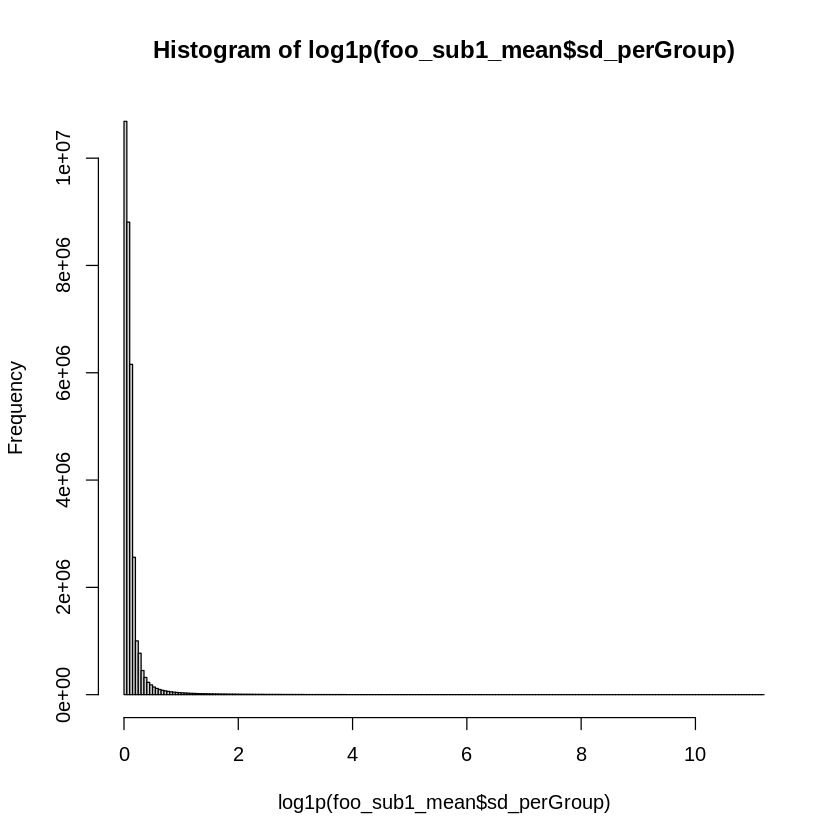

png 
  2

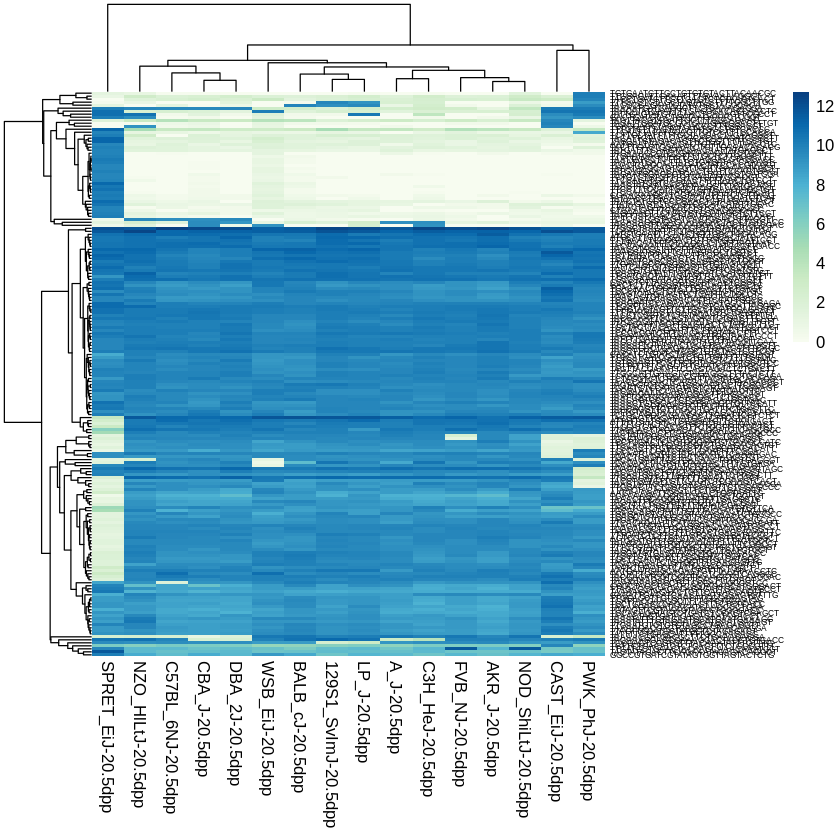

In [32]:

##NEXT IS THE TOP 15% VARIANT miRNA plot on the means. Then the subset more useful miRNA plot
library(pheatmap)

foo_sub_1 <- as.data.frame.matrix(foo_sub_1) #convert from matrix to data frame
## use for eg foo$`hPGC_M_Wk9_n1` <- foo$`hPGC-M-Wk9_2` if only want one biol replicate

colnames(foo_sub_1)

head(foo_sub_1[ , grepl( "^129S1_SvImJ-12.5dpp" , names( foo_sub_1 ) ) ])
foo_sub1_mean = data.frame(matrix(NA, nrow = nrow(foo_sub_1), ncol = 0))
row.names(foo_sub1_mean) <- row.names(foo_sub_1)
for (sample in samplenames) {
foo_sub1_mean[sample] <- apply(foo_sub_1[ , grepl(paste0( "^",sample) , names( foo_sub_1 ) ) ], 1, mean)
}
head(foo_sub1_mean) 

foo_sub1_mean$sd_perGroup <- apply(foo_sub1_mean,1,sd)
hist(log1p(foo_sub1_mean$sd_perGroup),breaks = 200)


nrow(foo_sub1_mean)
3959
foo_sub1_mean_top15sd <- foo_sub1_mean[foo_sub1_mean$sd_perGroup>3959,1:16]
head(foo_sub1_mean_top15sd)
foo_sub1_mean_top15sd$ID<-rownames(foo_sub1_mean_top15sd)
head(foo_sub1_mean_top15sd)



save_pheatmap_pdf <- function(x, filename, width=15, height=25) {
    stopifnot(!missing(x))
    stopifnot(!missing(filename))
    pdf(filename, width=width, height=height,paper="special")
    grid::grid.newpage()
    grid::grid.draw(x$gtable)
    dev.off()
}

savePheatmap <- pheatmap(log1p(foo_sub1_mean_top15sd[,1:16]),width=28000,height=50000, border_color = NA,show_rownames = T, cluster_cols = T, labels_row = foo_sub1_mean_top15sd$ID,fontsize_row = 5, color = hmcol)
save_pheatmap_pdf(savePheatmap,"InitialPheatMap_20.5dpp.pdf")



png 
  2

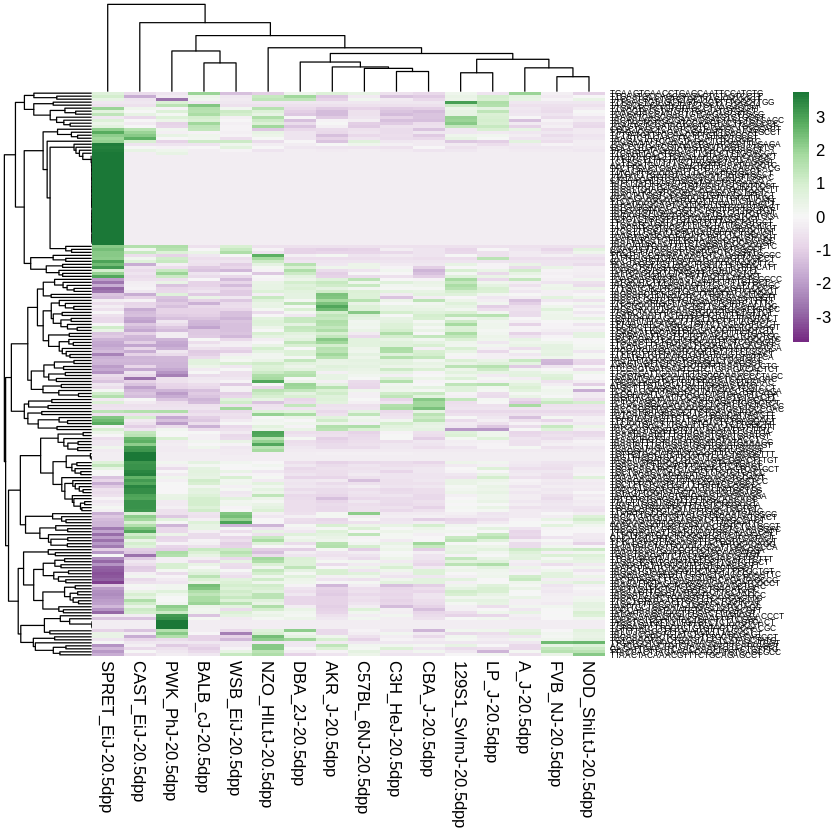

In [33]:

##for z-score
myCol = colorRampPalette(brewer.pal(9,"PRGn"))(100)

savePheatmapZScore <- pheatmap(foo_sub1_mean_top15sd[,1:16],,width=28000,height=50000, border_color = NA,show_rownames = T, cluster_cols = T,scale = "row",labels_row = foo_sub1_mean_top15sd$ID,fontsize_row = 5, color = myCol)
save_pheatmap_pdf(savePheatmapZScore,"InitialPheatMap_zScore_20.5dpp.pdf")

